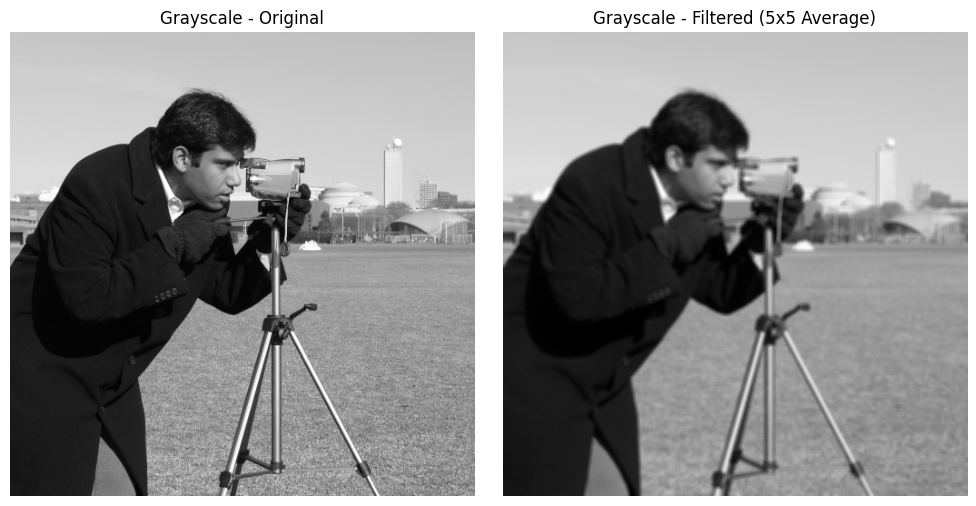

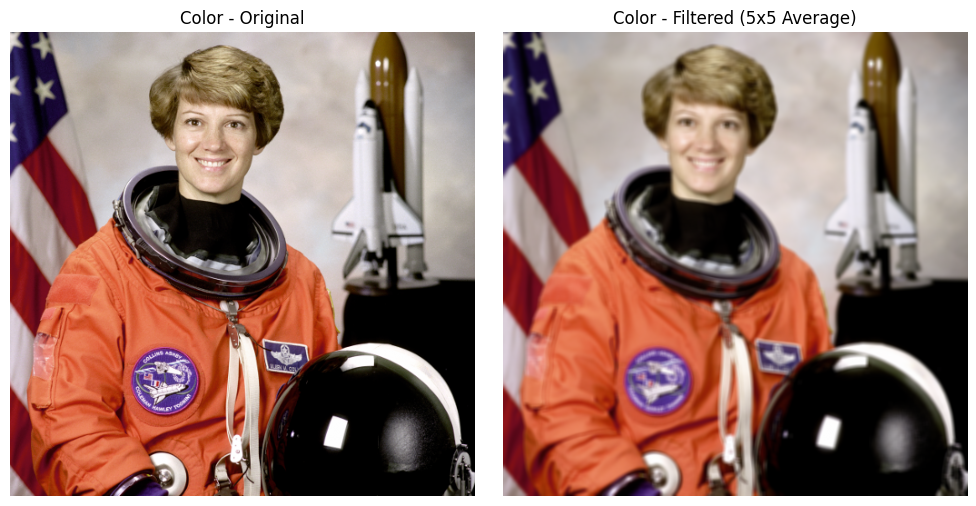

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# --------------------------------------------------
# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE
# --------------------------------------------------

# A. Memuat citra grayscale (camera)
gray_uint8 = data.camera()  # range 0..255
gray_img = img_as_float(gray_uint8)  # konversi menjadi float [0..1] untuk kemudahan

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Lakukan konvolusi pada citra grayscale
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) FILTER RATA-RATA PADA CITRA BERWARNA
# --------------------------------------------------

# A. Memuat citra berwarna (astronaut)
color_uint8 = data.astronaut()  # citra RGB (uint8, 0..255)
color_img = img_as_float(color_uint8)  # konversi float [0..1]

# B. Kita akan terapkan filter rata-rata pada tiap kanal R, G, B
# secara terpisah, lalu gabungkan.
color_filtered = np.zeros_like(color_img)

for c in range(3): 
    channel_original = color_img[:, :, c]
    channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
    color_filtered[:, :, c] = channel_filtered

# C. Tampilkan hasil
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()